# PCA(Principle Component Analysis)

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
# create a dataset 
X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
])
print(X)

[[2.5 2.4]
 [0.5 0.7]
 [2.2 2.9]
 [1.9 2.2]
 [3.1 3. ]
 [2.3 2.7]
 [2.  1.6]
 [1.  1.1]
 [1.5 1.6]
 [1.1 0.9]]


In [3]:
# calculate the mean 
mean =np.mean(X,axis =0)
print("Mean :",mean)

Mean : [1.81 1.91]


In [4]:
# now center the data
X_center =X-mean
print("Centered Data :",X_center)

Centered Data : [[ 0.69  0.49]
 [-1.31 -1.21]
 [ 0.39  0.99]
 [ 0.09  0.29]
 [ 1.29  1.09]
 [ 0.49  0.79]
 [ 0.19 -0.31]
 [-0.81 -0.81]
 [-0.31 -0.31]
 [-0.71 -1.01]]


In [5]:
# Calculate the covariance matrix 
covariance_matrix =np.cov(
    X_center,
    rowvar = False
)
print("Covariance Matrix :",covariance_matrix)

Covariance Matrix : [[0.61655556 0.61544444]
 [0.61544444 0.71655556]]


In [6]:
# calculate the eigen value and eigen vector for covariance matrix 
eigenvalue ,eigenvector  = np.linalg.eig(covariance_matrix)
print("Eigen Value :",eigenvalue)
print("Eigen Vector:",eigenvector)

Eigen Value : [0.0490834  1.28402771]
Eigen Vector: [[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]


In [7]:
#Sort the eigen value we need largest one as PC1
indices =np.argsort(eigenvalue)[::-1]
eigenvalue = eigenvalue[indices]
eigenvector = eigenvector[:,indices]

print("Sorted eigen values :",eigenvalue )
print("Sorted eigen vector :",eigenvector)

Sorted eigen values : [1.28402771 0.0490834 ]
Sorted eigen vector : [[-0.6778734  -0.73517866]
 [-0.73517866  0.6778734 ]]


In [8]:
# Calculate the explained variance 
explained_variance  = (eigenvalue/np.sum(eigenvalue))
print("Explained Variance :",explained_variance)

Explained Variance : [0.96318131 0.03681869]


In [9]:
# Select the principle component 
n_component =1
components =eigenvector[:,:n_component]
print("Selected Component :",components)

Selected Component : [[-0.6778734 ]
 [-0.73517866]]


In [10]:
# Projection (using dot product)
X_reduced =np.dot(X_center,components)
print("reduced data :",X_reduced)

reduced data : [[-0.82797019]
 [ 1.77758033]
 [-0.99219749]
 [-0.27421042]
 [-1.67580142]
 [-0.9129491 ]
 [ 0.09910944]
 [ 1.14457216]
 [ 0.43804614]
 [ 1.22382056]]


In [11]:
# Shape of our data
print("Original Shape :",X.shape)
print("Reduced Shape :",X_reduced.shape)

Original Shape : (10, 2)
Reduced Shape : (10, 1)


## Code Implementation 

In [13]:
# creating a dataset
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)
df = df.sample(40)

In [14]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [16]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 103.3 kB/s  0:01:51a 0:00:030:00:05:09
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]━━━━ 1/2 [plotly]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [17]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()
     

In [18]:
# Apply Standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df.iloc[:,0:3] = sc.fit_transform(df.iloc[:,0:3])

In [19]:
# Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [20]:
# Find eigen value and eigenvector 
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [21]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [22]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

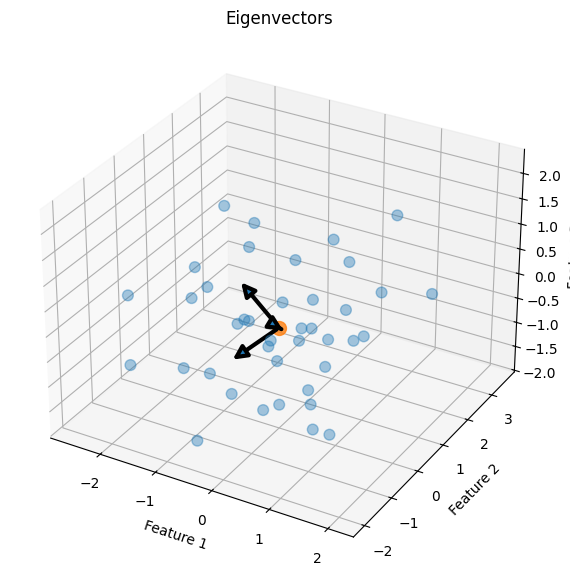

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(
            self,
            (0, 0),
            (0, 0),
            *args,
            **kwargs
        )
        self._verts3d = xs, ys, zs

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        return np.min(zs)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        FancyArrowPatch.draw(self, renderer)


fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(
    111,
    projection='3d'
)


# Plot data points
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    s=60,
    alpha=0.4
)


# Mean / centroid
mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()

ax.scatter(
    mean_x,
    mean_y,
    mean_z,
    s=100,
    alpha=0.8
)


# Plot eigenvectors
for v in eigen_vectors.T:

    arrow = Arrow3D(
        [mean_x, mean_x + v[0]],
        [mean_y, mean_y + v[1]],
        [mean_z, mean_z + v[2]],

        mutation_scale=20,
        lw=3,
        arrowstyle="-|>"
    )

    ax.add_artist(arrow)


ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

plt.title('Eigenvectors')

plt.show()

In [25]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [26]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [27]:

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

# Practical Example on MNIST Dataset

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

In [24]:
df =pd.read_csv("DATASET/digit-recognizer/train.csv")
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,...,pixel744,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [25]:
df.shape

(42000, 785)

In [26]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,...,pixel744,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
8370,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


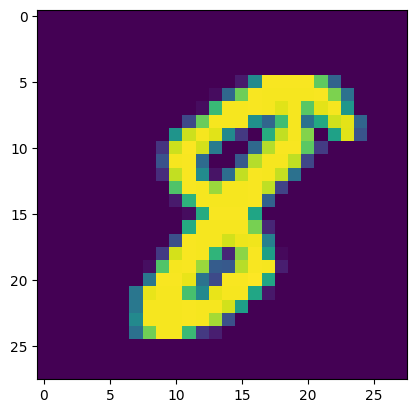

In [27]:
# show the image 
plt.imshow(df.iloc[24075,1:].values.reshape(28,28))

In [28]:
# dependent and independent variable 
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [9]:
X_train.shape

(31500, 784)

In [10]:
# train model 
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
# now make prediction(this take lot of time )
y_pred = knn.predict(X_test)
y_pred 

array([8, 1, 9, ..., 7, 4, 4], shape=(10500,))

In [12]:
# Measure its accuracy 
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9666666666666667


In [30]:
# Now use PCA to optimize it 
# Standardize the data 
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
# fit_transform 
X_train_pca = sc.fit_transform(X_train)
X_test_pca = sc.transform(X_test)

In [31]:
# Sklearn implementation of PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=100)

#apply to train and test data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [32]:
# check the shape of data 
X_train_pca.shape

(31500, 100)

In [33]:
# train a model 
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_pca,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [36]:
y_pred = knn.predict(X_test_pca)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.9707619047619047

In [37]:
# loop over principle component
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)  

    knn = KNeighborsClassifier()
    knn.fit(X_train_pca,y_train)

    y_pred = knn.predict(X_test_pca)
    print(accuracy_score(y_test,y_pred))


0.2755238095238095
0.41714285714285715
0.4837142857142857
0.6158095238095238
0.7316190476190476
0.819047619047619
0.8677142857142857
0.8945714285714286
0.9076190476190477
0.9237142857142857
0.931047619047619
0.9413333333333334
0.9494285714285714
0.9547619047619048
0.9544761904761905
0.9600952380952381
0.9617142857142857
0.9633333333333334
0.9652380952380952
0.9662857142857143
0.9665714285714285
0.969047619047619
0.9697142857142858
0.9702857142857143
0.9711428571428572
0.9714285714285714
0.9719047619047619
0.971047619047619
0.9717142857142858
0.9713333333333334
0.9727619047619047
0.9726666666666667
0.9721904761904762
0.9729523809523809
0.9719047619047619
0.9726666666666667
0.9726666666666667
0.9726666666666667
0.9737142857142858
0.9725714285714285
0.9720952380952381
0.9725714285714285
0.9729523809523809
0.9727619047619047
0.9728571428571429
0.9733333333333334
0.9740952380952381
0.9738095238095238
0.9737142857142858
0.9736190476190476
0.9727619047619047
0.973047619047619
0.97295238095238

### PCA for visualization

In [43]:
# 2D
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [44]:
X_train_trf

array([[-556.56612817, -508.27837152],
       [-411.02613052,  -12.54271578],
       [ 334.62121354,   88.50957175],
       ...,
       [ -30.77698958, -599.23777643],
       [ 227.07332266,  -22.22927202],
       [1097.05981329,  251.02448389]], shape=(31500, 2))

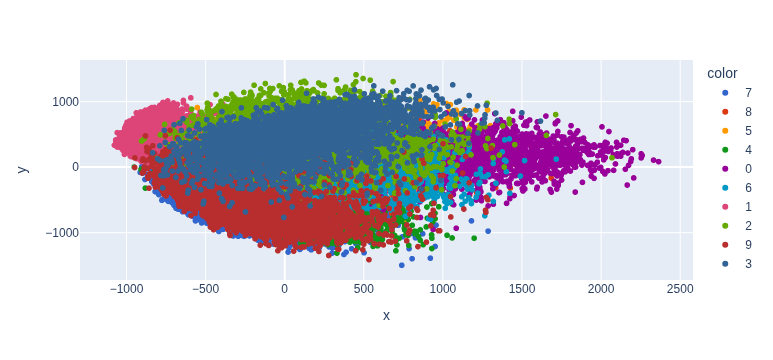

In [42]:
import plotly.express as px
y_train_trf =y_train.astype(str)
fig = px.scatter(x =X_train_trf[:,0],
                 y = X_train_trf[:,1],
                color =y_train_trf,color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

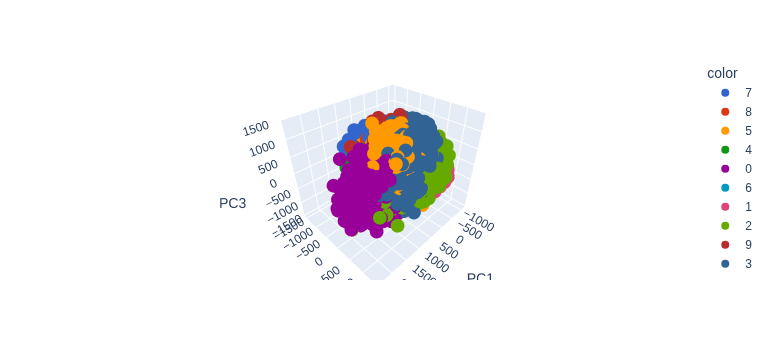

In [46]:
# 3D
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    z=X_train_trf[:, 2],
    color=y_train_trf,
    labels={
        "x": "PC1",
        "y": "PC2",
        "z": "PC3"
    },
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

In [48]:
pca.explained_variance_
# this is eigen value 

array([336192.56962333, 244310.58383151, 212295.65706188])

In [50]:
pca.components_.shape
# this is eigen vector 

(3, 784)

In [52]:
# percentage of variance explained by principle component for data
print((pca.explained_variance_ratio_)*100)

[9.79125172 7.11528642 6.18288566]


In [53]:
# Find the optimum number of PC required to explain 100 percent 
# variance of data 
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [54]:
# apply cumulative sum on expalined variance
np.cumsum(pca.explained_variance_ratio_)

array([0.09791252, 0.16906538, 0.23089424, 0.2847911 , 0.33381738,
       0.3770494 , 0.4097981 , 0.43867743, 0.46644185, 0.48973103,
       0.51066535, 0.53115819, 0.5482733 , 0.56503397, 0.58087841,
       0.59574169, 0.60896883, 0.62180859, 0.63362416, 0.64512335,
       0.655902  , 0.66611984, 0.6757911 , 0.68495729, 0.69380193,
       0.70211865, 0.71027553, 0.71801706, 0.72543691, 0.73235688,
       0.73897711, 0.74530737, 0.75133641, 0.75723212, 0.76285646,
       0.7682551 , 0.77333338, 0.77819742, 0.78292152, 0.78757112,
       0.79209836, 0.79654046, 0.80069492, 0.80463361, 0.80847636,
       0.81221367, 0.81581111, 0.81928988, 0.82263322, 0.82581119,
       0.82895189, 0.8320194 , 0.83493983, 0.83780513, 0.84059938,
       0.84328292, 0.84593868, 0.84850838, 0.85103652, 0.85349038,
       0.85589809, 0.85828779, 0.8605583 , 0.86278432, 0.86493383,
       0.86699235, 0.86901086, 0.87097459, 0.8729098 , 0.87479648,
       0.87665138, 0.87846472, 0.88022289, 0.88194709, 0.88359

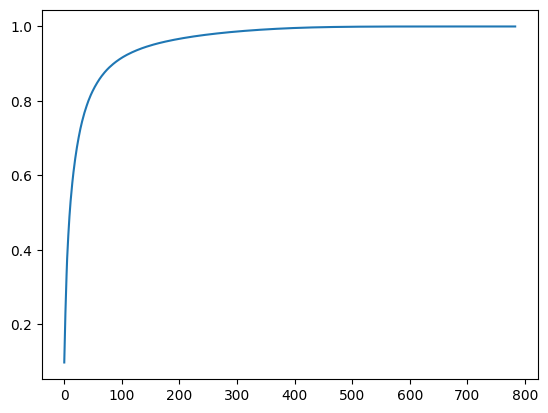

In [55]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))